<div style="text-align:center;">
  <h1 size=10>
    <b>BIG DATA ANALYTICS PROJECT</b><br>
    <b>Baldness Classification</b>
  </h1>
</div>

<h2 style="text-align:center;">
Master's in Data Science and Advanced Analytics - NOVA IMS (25/26)
</h2>

**Group 26**
- Bárbara Franco (20250388)
- Catarina Mendinhas (20250422)
- Maria Miguel Fonseca (20250380)
- Rodrigo Santos (20250387)
- Rodrigo Teixeira (20250393)

**GitHub repository:**  https://github.com/mariamiguel720/Big-Data-Analytics-Project-25-26

<font color='#2f94d7' size=6>**TABLE OF CONTENTS**</font> <a class="anchor" id='toc'></a>

- [1. Project Overview](#1)
- [2. Set Up & Import Libraries](#2)
- [3. Load Data](#3)
- [4. Data Exploration](#4)
- [5. Data Exploration](#5)
- [6. Undersampling](#6)
- [7. Data Quality Checks](#7)
- [8. Data Split](#8)
- [9. Outlier Analysis](#9)


# <font color='#2f94d7' size=6>**1. Project Overview**</font> <a class="anchor" id="1"></a>

[Back to TOC](#toc)

This notebook is developed in the context of a consulting engagement for a client operating 
in the computer vision space. The client requires a scalable solution to automatically 
classify facial images as **Bald** or **Not Bald**, a binary image classification problem.

Given the large volume of image data involved (+200k images), **Apache Spark (PySpark)** 
is used as the core processing framework, ensuring the pipeline is designed to scale 
horizontally across distributed environments.


# <font color='#2f94d7' size=6>**2. Set Up & Import Libraries**</font> <a class="anchor" id="2"></a>

[Back to TOC](#toc)

In [1]:
!pip install pyspark huggingface_hub python-dotenv
! pip install "pandas>=2.2.0" --upgrade

In [2]:
# IMPORT LIBRARIES
import random
import os
import io
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from PIL import Image
import io

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import StringType
from pyspark.sql import Row
from pyspark.sql.types import StructType, StructField, StringType, FloatType, ArrayType, DoubleType

from pyspark.ml.feature import VectorAssembler
from pyspark.ml.stat import Summarizer
from pyspark.ml.linalg import Vectors
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator


from scipy.ndimage import uniform_filter, sobel as scipy_sobel

In [3]:
# Install Java 17 (Required for Spark)
!sudo apt-get update
!sudo apt-get install -y openjdk-17-jdk-headless
!java -version

Hit:1 https://download.docker.com/linux/ubuntu noble InRelease
Hit:2 https://cli.github.com/packages stable InRelease                         
Hit:3 https://packages.cloud.google.com/apt cloud-sdk InRelease                
Hit:4 https://us-east-1.ec2.archive.ubuntu.com/ubuntu noble InRelease          
Hit:5 https://us-east-1.ec2.archive.ubuntu.com/ubuntu noble-updates InRelease  
Hit:6 https://us-east-1.ec2.archive.ubuntu.com/ubuntu noble-backports InRelease
Hit:7 http://deb.wakemeops.com/wakemeops stable InRelease                      
Hit:8 https://security.ubuntu.com/ubuntu noble-security InRelease              
Hit:9 https://cloud.archive.ubuntu.com/ubuntu noble InRelease       
Hit:10 https://archive.ubuntu.com/ubuntu noble InRelease
Hit:11 https://cloud.archive.ubuntu.com/ubuntu noble-updates InRelease
Hit:12 https://archive.ubuntu.com/ubuntu noble-updates InRelease
Hit:13 https://cloud.archive.ubuntu.com/ubuntu noble-backports InRelease
Hit:14 https://archive.ubuntu.com/ubuntu n

Reading package lists... Done
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
openjdk-17-jdk-headless is already the newest version (17.0.19+10-1~24.04.2).
0 upgraded, 0 newly installed, 0 to remove and 54 not upgraded.
openjdk version "17.0.19" 2026-04-21
OpenJDK Runtime Environment (build 17.0.19+10-1-24.04.2-Ubuntu)
OpenJDK 64-Bit Server VM (build 17.0.19+10-1-24.04.2-Ubuntu, mixed mode, sharing)


In [4]:
# Set JAVA_HOME and initialize Spark Session with specific configurations
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-17-openjdk-amd64"


spark = (
    SparkSession.builder
    .master("local[*]")
    .appName("BaldClassification")
    .config("spark.driver.memory", "12g") # RAM for the driven
    .config("spark.sql.files.maxPartitionBytes", "128m")
    .getOrCreate()
)


spark.sparkContext.setLogLevel("WARN")
print(f"Spark version: {spark.version}")

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/05/29 10:10:07 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Spark version: 4.1.2


In [5]:
	# DEFINE DATA PATHS
BASE_PATH = os.path.abspath(os.path.join(os.getcwd(), "../../data/Data_Bald_People/Raw"))
SPLITS    = ["Train", "Validation", "Test"]
LABELS    = ["Bald", "NotBald"]

In [6]:
# REPRODUCIBILITY
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# <font color='#2f94d7' size=6>**3. Load Data**</font> <a class="anchor" id="3"></a>

[Back to TOC](#toc)

Images are loaded using Spark's native `binaryFile` format, which reads each image as a 
row containing its path, raw binary content, and file size. This approach is big-data-safe 
as it leverages Spark's distributed file reading capabilities and does not rely on local I/O.

Each subset (split × label combination) is loaded separately and tagged with its 
corresponding label and split metadata before being unioned into a single DataFrame.

In [7]:
# Collect individual DataFrames for each split/label combination
dfs = []

for split in SPLITS:
    for label in LABELS:
        folder = os.path.join(BASE_PATH, split, label)

        df_part = (
            spark.read.format("binaryFile")
            .option("pathGlobFilter", "*.jpg")   # filter to JPEG images only
            .option("recursiveFileLookup", "false")  # images are directly in the folder, no subdirectories
            .load(folder)
            .select(
                F.col("path"),
                F.col("content"),                          # raw image bytes
                F.col("length").alias("file_size_bytes"),  # file size in bytes
            )
            .withColumn("label",          F.lit(label))
            .withColumn("label_index",    F.lit(1 if label == "Bald" else 0).cast("integer"))  # Bald=1, NotBald=0
            .withColumn("original_split", F.lit(split))
        )

        dfs.append(df_part)
        print(f"  Loaded {split}/{label}")

# Union all partial DataFrames into a single DataFrame
df_all = dfs[0]
for df in dfs[1:]:
    df_all = df_all.union(df)

# Cache the unified DataFrame to avoid re-reading files in subsequent operations
df_all.cache()
print(f"\nTotal images loaded: {df_all.count():,}")

  Loaded Train/Bald


26/05/29 10:10:25 WARN SharedInMemoryCache: Evicting cached table partition metadata from memory due to size constraints (spark.sql.hive.filesourcePartitionFileCacheSize = 262144000 bytes). This may impact query planning performance.


  Loaded Train/NotBald
  Loaded Validation/Bald
  Loaded Validation/NotBald
  Loaded Test/Bald
  Loaded Test/NotBald



Total images loaded: 202,599


In [8]:
# Repartition to consolidate the large number of partitions inherited from binaryFile reads.
# binaryFile creates one partition per file group, resulting in 12k+ partitions for this dataset.
# With only 13k images after undersampling, this means ~1 image per partition — extremely inefficient.
# Repartitioning to 8 partitions reduces task overhead significantly for all subsequent operations.
# NOTE: repartition() triggers a full shuffle — this one-time cost is justified by the
# performance gains in all downstream operations (feature extraction, K-Means, aggregations).
df_all = df_all.repartition(8).cache()

# <font color='#2f94d7' size=6>**4. Data Exploration**</font> <a class="anchor" id="4"></a>

[Back to TOC](#toc)

## <font color='#2f94d7' size=6>**4.1 Class Distribution**</font> <a class="anchor" id="4_1"></a>

[Back to TOC](#toc)

The metadata DataFrame (excluding raw image bytes) is registered as a Spark SQL temporary 
view to enable SQL-style querying. This demonstrates Spark's ability to mix DataFrame 
and SQL APIs seamlessly.

The distribution of images across splits and classes is computed to quantify the severity 
of the class imbalance identified in the Project Overview.

In [9]:
# Drop the raw image content column to create a lightweight metadata-only DataFrame
# This avoids carrying binary data through aggregations, which is critical at scale
df_meta = df_all.drop("content")
df_meta.createOrReplaceTempView("image_metadata")

# Query the distribution of images per split and label using SparkSQL
# NOTE: ORDER BY in SQL is not guaranteed to be stable across distributed partitions.
# This is acceptable here as the query is used only for display purposes.
df_dist = spark.sql("""
    SELECT original_split, label, COUNT(*) AS n_images
    FROM image_metadata
    GROUP BY original_split, label
    ORDER BY original_split, label
""")
df_dist.show()

# Aggregate total counts per class across all splits
# NOTE: toPandas() collects all data to the driver node and is not big-data-safe.
# It is used here only because the aggregated result is a very small DataFrame (2 rows).
class_counts = (
    df_dist.groupBy("label")
    .agg(F.sum("n_images").alias("n"))
    .toPandas()
)

n_bald    = int(class_counts.loc[class_counts.label == "Bald",    "n"].values[0])
n_notbald = int(class_counts.loc[class_counts.label == "NotBald", "n"].values[0])

print(f"Bald    : {n_bald:,}")
print(f"NotBald : {n_notbald:,}")
print(f"Imbalance ratio: {round(max(n_bald, n_notbald) / min(n_bald, n_notbald), 2)}x")

# Compute the proportion of images belonging to the Train split
# NOTE: collect() is used here to retrieve a single aggregated scalar value.
# This is acceptable as the result is a single row, not a large collection.
train_total = df_dist.filter(F.col("original_split") == "Train").agg(F.sum("n_images")).collect()[0][0]
total = df_all.count()
print(f"Train split share: {round(train_total / total * 100, 1)}%")

+--------------+-------+--------+
|original_split|  label|n_images|
+--------------+-------+--------+
|          Test|   Bald|     421|
|          Test|NotBald|   19579|
|         Train|   Bald|    3656|
|         Train|NotBald|  156344|
|    Validation|   Bald|     470|
|    Validation|NotBald|   22129|
+--------------+-------+--------+

Bald    : 4,547
NotBald : 198,052
Imbalance ratio: 43.56x
Train split share: 79.0%


**Key findings:**
- The dataset is heavily imbalanced: NotBald images outnumber Bald by a ratio of **43.56x**
- This imbalance is consistent across all three splits, confirming it is a structural 
  property of the dataset and not an artifact of the split process
- The Train split dominates the dataset, containing ~78% of all images

## <font color='#2f94d7' size=6>**4.2 Visual Sample Inspection**</font> <a class="anchor" id="4_2"></a>

[Back to TOC](#toc)

A random sample of images from each class is displayed to allow qualitative assessment 
of image quality, label correctness, and visual diversity within each class.

/tmp/ipykernel_21426/999549204.py:29: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


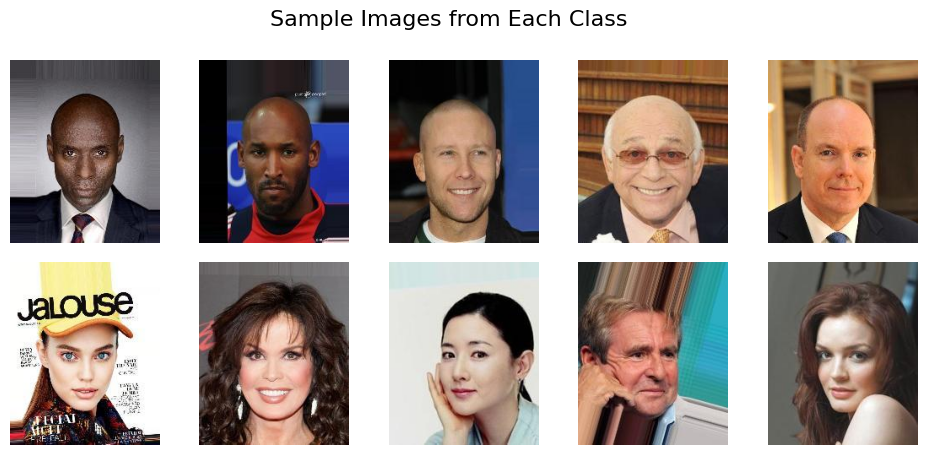

In [ ]:
# Visualise a random sample of images from each class to inspect data quality
# NOTE: orderBy(F.rand()) is not fully deterministic in distributed environments,
# as the result may vary depending on the number of partitions at runtime.
# A seed is provided for best-effort reproducibility in single-node execution.
# NOTE: toPandas() and iterrows() are used here only because the sample is very small
# (n_samples=5 per class). This would not be appropriate for large collections of images.
n_samples = 5
fig = plt.figure(figsize=(12, 5))
gs = gridspec.GridSpec(2, n_samples, wspace=0.1, hspace=0.1)

for i, label in enumerate(LABELS):
    df_sample = (
        df_all.filter(F.col("label") == label)
        .orderBy(F.rand(seed=42))
        .limit(n_samples)
        .toPandas()
    )

    for j, (_, row) in enumerate(df_sample.iterrows()):
        img_bytes = row["content"]
        img = Image.open(io.BytesIO(img_bytes))
        ax = fig.add_subplot(gs[i, j])
        ax.imshow(img)
        ax.axis("off")
        if j == 0:
            ax.set_ylabel(label, fontsize=12, rotation=0, labelpad=40)

plt.suptitle("Sample Images from Each Class", fontsize=16)
plt.tight_layout()
plt.show()

> **Observation:** Visual inspection of the sample images reveals at least one potential 
> mislabelling in the Bald class. This will be revisited during the Outlier Analysis 
> section, where numeric features extracted from the images will be used to identify 
> and flag anomalous samples.

# <font color='#2f94d7' size=6>**5. Undersampling**</font> <a class="anchor" id="5"></a>

[Back to TOC](#toc)

To address the severe class imbalance (43.56x), the NotBald class is undersampled to 
achieve a **2:1 ratio** (NotBald:Bald). This is done using Spark's native `.sample()` 
method, which performs distributed approximate sampling, making it big-data-safe.

The Bald class is kept in full, as it is the minority class and every sample is valuable 
for training.

In [ ]:
# n_bald and n_notbald are reused from Section 4 — no need to recompute

# Bald is the minority class; set the NotBald target to 2x the number of Bald samples (2:1 ratio)
n_notbald_target = n_bald * 2

# Compute the sampling fraction needed to reach the target count
# NOTE: Spark's sample() uses approximate sampling, so the actual result may differ
# slightly from the target. This is acceptable for the purpose of balancing the dataset.
fraction = n_notbald_target / n_notbald

print(f"Bald    (minority class)  : {n_bald:,}")
print(f"NotBald (majority class)  : {n_notbald:,}")
print(f"NotBald target (2:1)      : {n_notbald_target:,}")
print(f"Sampling fraction         : {fraction:.4f}")

# Undersample the NotBald class to the target fraction
df_notbald_sampled = (
    df_all
    .filter(F.col("label") == "NotBald")
    .sample(fraction=fraction, seed=42)
)

# Combine the full Bald class with the undersampled NotBald class
df_bald     = df_all.filter(F.col("label") == "Bald")
df_balanced = df_bald.union(df_notbald_sampled)

# Verify the resulting class distribution
# NOTE: orderBy is not guaranteed to be stable across distributed partitions;
# used here for display purposes only
df_balanced.groupBy("label").count().orderBy("label").show()
print(f"Total after undersampling: {df_balanced.count():,}")

# Cache the balanced DataFrame and release the original to free memory
# Caching is critical to avoid recomputing the sampling in subsequent operations
df_balanced.cache()
df_all.unpersist()

Bald    (minority class)  : 4,547
NotBald (majority class)  : 198,052
NotBald target (2:1)      : 9,094
Sampling fraction         : 0.0459
+-------+-----+
|  label|count|
+-------+-----+
|   Bald| 4547|
|NotBald| 9088|
+-------+-----+

Total after undersampling: 13,635


DataFrame[path: string, content: binary, file_size_bytes: bigint, label: string, label_index: int, original_split: string]

**Key findings:**
- After undersampling, the dataset is reduced from 202,599 to **13,673 images**
- The final ratio is approximately 2:1 (NotBald:Bald), as intended
- Note that Spark's `.sample()` is approximate, the actual NotBald count (9,126) 
  differs slightly from the target (9,094), which is expected behaviour

# <font color='#2f94d7' size=6>**7. Data Quality Checks**</font> <a class="anchor" id="7"></a>

[Back to TOC](#toc)

Two basic quality filters are applied to the balanced dataset:
- **Null content filter**: removes any records where the image binary content is missing 
  or could not be read by Spark
- **Minimum file size filter**: removes files smaller than 1,000 bytes, which are likely 
  corrupt, truncated, or placeholder images

> **Note:** A formal Spark Pipeline is not used here, as the quality checks consist of 
> simple DataFrame filters rather than feature transformations. Model-specific transforms 
> (e.g. resize, normalisation) are applied at the DataLoader level in the modelling stage.

In [ ]:
# Record total image count before applying quality filters
total_before = df_balanced.count()
print(f"Total before quality filter : {total_before:,}")

# Apply quality filters:
# 1. Remove records where image content is null (unreadable or missing files)
# 2. Remove files smaller than 1000 bytes (likely corrupt or placeholder images)
df_quality = (
    df_balanced
    .filter(F.col("content").isNotNull())
    .filter(F.length(F.col("content")) >= 1000)
)
df_quality.cache()
df_balanced.unpersist()  # release the balanced DataFrame to free memory

# Record total after filtering and compute number of removed images
total_after = df_quality.count()
removed     = total_before - total_after

print(f"Total after quality filter  : {total_after:,}")
print(f"Removed                     : {removed:,}")

Total before quality filter : 13,635
Total after quality filter  : 13,635
Removed                     : 0


**Key findings:**
- No images were removed by the quality filters (0 records flagged)
- This confirms that the dataset, as downloaded from Kaggle, contains no null or 
  corrupt files in the balanced subset
- The filtered DataFrame (`df_quality`) with **13,673 images** is carried forward 
  to the next stage

# <font color='#2f94d7' size=6>**8. Data Split**</font> <a class="anchor" id="8"></a>

[Back to TOC](#toc)



The quality-filtered dataset is split into Train, Validation, and Test subsets using a 
**70/15/15** ratio. To ensure the 2:1 class ratio is preserved across all subsets, the 
split is performed **separately per class** (stratified split) before unioning the results.

In [ ]:
# Stratified split by label: perform randomSplit separately per class to preserve
# the 2:1 class ratio across all three subsets.
# NOTE: randomSplit is non-deterministic across partitions and is therefore not
# fully big-data-safe for exact reproducibility. In production, a hash-based
# split (e.g. on a row ID) would be preferred. It is used here as it is the
# standard Spark approach for dataset splitting.

df_bald_split    = df_quality.filter(F.col("label") == "Bald")
df_notbald_split = df_quality.filter(F.col("label") == "NotBald")

train_bald,    val_bald,    test_bald    = df_bald_split.randomSplit([0.7, 0.15, 0.15],    seed=SEED)
train_notbald, val_notbald, test_notbald = df_notbald_split.randomSplit([0.7, 0.15, 0.15], seed=SEED)

train_df = train_bald.union(train_notbald)
val_df   = val_bald.union(val_notbald)
test_df  = test_bald.union(test_notbald)

# Cache splits as they will be reused in the Outlier Analysis section
train_df.cache()
df_quality.unpersist() # release the quality-filtered DataFrame to free memory

print(f"Train      : {train_df.count():,}")
print(f"Validation : {val_df.count():,}")
print(f"Test       : {test_df.count():,}")

Train      : 9,593
Validation : 2,000
Test       : 2,042


The 2:1 class ratio (NotBald:Bald) is preserved across all three splits and the splits are cached to avoid recomputation in the Outlier Analysis section

# <font color='#2f94d7' size=6>**9. Outliers Analysis**</font> <a class="anchor" id="9"></a>

[Back to TOC](#toc)

Outlier detection is applied exclusively to the **training set** to avoid any influence 
on the validation and test sets, which must remain untouched for unbiased evaluation.

The goal is to identify and understand anomalous or potentially mislabelled images 
before training. The analysis follows a structured progression of three approaches, 
each building on the limitations identified in the previous one:

1. **Texture and Sobel Gradient Features** — handcrafted features are extracted from 
   each image to quantify visual properties associated with baldness (texture smoothness, 
   edge intensity, spatial gradients)

2. **Label-Based Outlier Detection (Centroid + Z-Score and IQR)** — the extracted 
   features are used to flag images that are statistically anomalous within their 
   labelled class. Two methods are explored: centroid-based Z-score thresholding and 
   IQR-based filtering

3. **Unsupervised Outlier Detection (K-Means)** — motivated by the limitations of 
   label-based approaches, K-Means clustering is applied without using labels to 
   assess whether the extracted features can separate the two classes independently 
   of the folder structure

A final conclusion synthesises the findings across all three approaches and justifies 
the decision on whether to remove outliers before training.

## <font color='#2f94d7' size=6>**9.1 Texture and Sobel Gradient**</font> <a class="anchor" id="9_1"></a>

[Back to TOC](#toc)

To detect mislabelled or anomalous images, handcrafted features are extracted from the 
raw image content using **Spark's `mapPartitions`**, a big-data-safe operation that 
processes one partition at a time without collecting data to the driver.

Features are based on **texture and edge gradients** rather than pixel colour values, 
making them robust to skin tone variation. The image is divided into three spatial zones 
(top, sides, transition) and 8 features are computed per image.

In [14]:
# Feature extraction function applied per partition using mapPartitions (big-data-safe)
# Using mapPartitions instead of a UDF allows imports to be done once per partition,
# reducing overhead significantly at scale.

IMG_SIZE  = 224
WIN_SIZE  = 16    # window size for local std computation
EPS       = 1e-6  # small constant to avoid division by zero

def local_std(zone, win=WIN_SIZE):
    """Computes local texture roughness (pixel-wise local standard deviation)."""
    mean_sq  = uniform_filter(zone ** 2, size=win)
    sq_mean  = uniform_filter(zone,      size=win) ** 2
    variance = np.maximum(mean_sq - sq_mean, 0)
    return float(np.sqrt(variance).mean())

def sobel_magnitude(zone):
    """Computes mean Sobel edge magnitude — detects edges regardless of skin colour."""
    sx = scipy_sobel(zone, axis=1)
    sy = scipy_sobel(zone, axis=0)
    return float(np.sqrt(sx**2 + sy**2).mean())

def extract_texture_features(rows):
    """
    Extracts texture and gradient features from image binary content.
    Processed partition by partition (mapPartitions) — imports done once per partition.

    Strategy: texture + gradient instead of absolute colour values.
    This makes features robust to skin tone, avoiding misclassification of
    dark-skinned bald individuals whose smooth scalp may resemble dark hair.

    Image zones (assumes images resized to IMG_SIZE x IMG_SIZE):
      - top    : upper 40% of image — should be smooth if bald
      - sides  : lower 30% left+right — lateral hair region
      - transition: horizontal band centred at top/sides boundary

    Extracted features:
      [0] std_local_topo       : mean local texture roughness at the top (8x8 window)
      [1] std_local_lados      : mean local texture roughness at the sides
      [2] ratio_texture        : std_local_topo / (std_local_lados + eps) — PRIMARY feature
      [3] sobel_topo           : mean edge intensity at the top (hair creates edges)
      [4] sobel_lados          : mean edge intensity at the sides
      [5] ratio_sobel          : sobel_topo / (sobel_lados + eps)
      [6] gradient_transition  : vertical gradient at the top/sides boundary
                                 (bald: abrupt transition; not bald: gradual)
      [7] std_topo_global      : global std of the top zone (complements local measure)
    """
    for row in rows:
        try:
            img_bytes = row["content"]
            if img_bytes is None or len(img_bytes) < 1000:
                continue

            # Convert image bytes to grayscale numpy array
            img = Image.open(io.BytesIO(img_bytes)).convert("L")
            arr = np.array(img, dtype=np.float32)
            h, w = arr.shape

            # Zone definition
            top_h  = int(h * 0.40)
            side_h = int(h * 0.30)
            side_w = int(w * 0.30)

            zone_top   = arr[:top_h, :]
            zone_left  = arr[top_h:top_h + side_h, :side_w]
            zone_right = arr[top_h:top_h + side_h, w - side_w:]
            zone_sides = np.concatenate([zone_left, zone_right], axis=1)

            # Transition band: ±10 pixels around the top/sides boundary
            trans_band      = 10
            y0              = max(0, top_h - trans_band)
            y1              = min(h, top_h + trans_band)
            zone_transition = arr[y0:y1, :]

            # Texture features (local std) 
            std_local_topo  = local_std(zone_top)
            std_local_lados = local_std(zone_sides)
            ratio_texture   = std_local_topo / (std_local_lados + EPS)

            # Gradient features (Sobel)
            sobel_topo  = sobel_magnitude(zone_top)
            sobel_lados = sobel_magnitude(zone_sides)
            ratio_sobel = sobel_topo / (sobel_lados + EPS)

            # Transition gradient
            # Bald: abrupt vertical gradient at boundary (high value)
            # Not bald with short hair: gradual transition (low value)
            gy                  = np.abs(np.diff(zone_transition, axis=0)).mean()
            gradient_transition = float(gy)

            # Global top std (complementary to local measure)
            std_topo_global = float(zone_top.std())

            features = [
                std_local_topo,
                std_local_lados,
                ratio_texture,
                sobel_topo,
                sobel_lados,
                ratio_sobel,
                gradient_transition,
                std_topo_global,
            ]

            yield Row(path=row["path"], label=row["label"], features_raw=features)

        except Exception:
            continue  # skip unreadable or corrupt images silently

# Define the output schema for the resulting DataFrame
feat_schema = StructType([
    StructField("path",         StringType(),          False),
    StructField("label",        StringType(),          False),
    StructField("features_raw", ArrayType(FloatType()), False),
])

# Apply feature extraction across all partitions of the training set
# NOTE: mapPartitions is big-data-safe — each partition is processed independently
rdd_feat = train_df.rdd.mapPartitions(extract_texture_features)
df_feat  = spark.createDataFrame(rdd_feat, schema=feat_schema)
df_feat.cache()
print(f"Images with extracted features: {df_feat.count():,}")

Images with extracted features: 9,593


In [15]:
# Expand the features_raw array into individual named columns for readability
FEAT_NAMES = [
    "std_local_topo", "std_local_lados", "ratio_texture",
    "sobel_topo",     "sobel_lados",     "ratio_sobel",
    "gradient_transition", "std_topo_global"
]

for i, name in enumerate(FEAT_NAMES):
    df_feat = df_feat.withColumn(name, F.col("features_raw")[i])

# Sanity check: compute per-class feature averages to verify discriminative power
# Expected pattern:
#   Bald    — low ratio_texture (smooth top vs rough sides)
#             low ratio_sobel   (few edges at the top)
#             high gradient_transition (abrupt top/sides boundary)
#   NotBald — ratio_texture ~1.0 (similar texture throughout)
#             ratio_sobel   ~1.0
#             low gradient_transition (gradual transition)
print("Per-class feature averages (sanity check):")
df_feat.groupBy("label").agg(
    *[F.round(F.avg(F.col(n)), 4).alias(n) for n in FEAT_NAMES]
).show(truncate=False)

Per-class feature averages (sanity check):
+-------+--------------+---------------+-------------+----------+-----------+-----------+-------------------+---------------+
|label  |std_local_topo|std_local_lados|ratio_texture|sobel_topo|sobel_lados|ratio_sobel|gradient_transition|std_topo_global|
+-------+--------------+---------------+-------------+----------+-----------+-----------+-------------------+---------------+
|Bald   |13.6609       |20.8039        |0.6862       |31.8991   |52.8012    |0.6239     |3.4934             |48.8892        |
|NotBald|18.6287       |23.8046        |0.8176       |47.2803   |62.9674    |0.7832     |4.8778             |57.0904        |
+-------+--------------+---------------+-------------+----------+-----------+-----------+-------------------+---------------+



!!! ATENÇÃO SE OS VALORES MENCIONADOS NÃO ESTÃO CERTOS

**Key findings:**
- `ratio_texture` is lower for Bald (0.689) than NotBald (0.8113), confirming 
  that bald images have a smoother top relative to the sides
- `gradient_transition` is lower for Bald (3.4838) than NotBald (4.8368), which 
  is contrary to the initial hypothesis, this feature may be less discriminative 
  than expected
- Overall the features show modest but consistent differences between classes, 
  sufficient as a basis for outlier detection

## <font color='#2f94d7' size=6>**9.2 Centroid Based Outlier Detection**</font> <a class="anchor" id="9_2"></a>

[Back to TOC](#toc)

Each image's extracted features are assembled into an MLlib-compatible Vector and used 
to compute its **squared Euclidean distance to its class centroid**. Images that are 
unusually far from their class centroid are flagged as potential outliers, they may be 
mislabelled or visually atypical for their class.

In [16]:
# Assemble the 8 individual feature columns into a single MLlib-compatible Vector column
# This is required by Spark MLlib algorithms, which expect a single 'features' column

assembler = VectorAssembler(inputCols=FEAT_NAMES, outputCol="features")
df_vec    = assembler.transform(df_feat).select("path", "label", "features")
df_vec.cache()
print("Schema:")
df_vec.printSchema()

Schema:
root
 |-- path: string (nullable = false)
 |-- label: string (nullable = false)
 |-- features: vector (nullable = true)



In [17]:
# Compute the per-class feature centroid (mean vector) using Spark MLlib's Summarizer
# Summarizer operates on distributed Vector columns and is big-data-safe
summarizer = Summarizer.mean(F.col("features"))

# The centroid must be collected to the driver to enable broadcasting.
# collect() is used on a single aggregated row, so the data transfer is negligible.
# The centroid is then broadcast to all workers, avoiding repeated serialization
# across partitions — this is the standard big-data-safe pattern for this use case.
centroid_bald = (
    df_vec.filter(F.col("label") == "Bald")
    .select(summarizer).collect()[0][0]
)
centroid_notbald = (
    df_vec.filter(F.col("label") == "NotBald")
    .select(summarizer).collect()[0][0]
)

print("\nBald centroid:")
for n, v in zip(FEAT_NAMES, centroid_bald):
    print(f"  {n:25s}: {v:.4f}")

print("\nNotBald centroid:")
for n, v in zip(FEAT_NAMES, centroid_notbald):
    print(f"  {n:25s}: {v:.4f}")

# Compute squared Euclidean distance from each image to its class centroid
# The centroid is broadcast to all workers to avoid repeated serialization — big-data-safe
# NOTE: UDFs are opaque to Spark's query optimizer. Here they are used because
# MLlib's Vectors.squared_distance is not natively available as a DataFrame
# function. The broadcast of the centroid ensures the UDF is efficient at scale.
def make_dist_udf(centroid):
    centroid_bc = spark.sparkContext.broadcast(centroid)
    @F.udf(DoubleType())
    def _udf(features):
        if features is None:
            return None
        return float(Vectors.squared_distance(features, centroid_bc.value))
    return _udf

dist_bald_udf    = make_dist_udf(centroid_bald)
dist_notbald_udf = make_dist_udf(centroid_notbald)

# Apply distance UDF per class and union the results
df_dist = (
    df_vec.filter(F.col("label") == "Bald")
    .withColumn("dist_to_centroid", dist_bald_udf(F.col("features")))
    .union(
        df_vec.filter(F.col("label") == "NotBald")
        .withColumn("dist_to_centroid", dist_notbald_udf(F.col("features")))
    )
)
df_dist.cache()

print("\nDistance statistics per class:")
df_dist.groupBy("label").agg(
    F.round(F.mean("dist_to_centroid"),   4).alias("mean"),
    F.round(F.stddev("dist_to_centroid"), 4).alias("std"),
    F.round(F.min("dist_to_centroid"),    4).alias("min"),
    F.round(F.max("dist_to_centroid"),    4).alias("max"),
).show()


Bald centroid:
  std_local_topo           : 13.6609
  std_local_lados          : 20.8039
  ratio_texture            : 0.6862
  sobel_topo               : 31.8991
  sobel_lados              : 52.8012
  ratio_sobel              : 0.6239
  gradient_transition      : 3.4934
  std_topo_global          : 48.8892

NotBald centroid:
  std_local_topo           : 18.6287
  std_local_lados          : 23.8046
  ratio_texture            : 0.8176
  sobel_topo               : 47.2803
  sobel_lados              : 62.9674
  ratio_sobel              : 0.7832
  gradient_transition      : 4.8778
  std_topo_global          : 57.0904

Distance statistics per class:


+-------+---------+---------+-------+----------+
|  label|     mean|      std|    min|       max|
+-------+---------+---------+-------+----------+
|   Bald|1177.7167|1923.7262| 3.9105|42276.9077|
|NotBald|1338.8009|2067.3309|10.0891|79131.5904|
+-------+---------+---------+-------+----------+



!!! ATENÇÃO SE OS VALORES MENCIONADOS NÃO ESTÃO CERTOS

**Key findings:**
- Bald images have a mean centroid distance of **1180.74** with a very high std 
  (1927.95) and a maximum of 42257.69, indicating the presence of extreme outliers
- NotBald images show a similar pattern (mean 1310.79, max 56136,29)
- The high standard deviation of centroid distances (1927 for Bald, 1691 for NotBald) 
  indicates that some samples are located far from their class centroid, making 
  centroid distance a useful signal for outlier detection within each class.
- However, the mean distances between classes are close (1180 for Bald vs 1310 for 
  NotBald), and the min/max ranges overlap significantly, meaning these features 
  alone are not sufficient to reliably distinguish Bald from NotBald samples.

## <font color='#2f94d7' size=6>**9.3 Z-Score Outlier Thresholding**</font> <a class="anchor" id="9_3"></a>

[Back to TOC](#toc)

An adaptive Z-score threshold is used to flag outliers: any image whose distance to 
its class centroid exceeds **mean + Z × std** is considered an outlier. Three values 
of Z are explored before selecting the final threshold.

In [18]:
# Z-score based adaptive threshold: threshold = mean + Z * std
# Advantage over a fixed percentile: if distances are compact (small std),
# the threshold tightens automatically and only removes genuine outliers,
# rather than always removing a fixed proportion of the data.

Z_THRESHOLD = 2.5  # tunable: 2.0 = more aggressive, 3.0 = more conservative

# Compute per-class mean and std of centroid distances
stats_rows = (
    df_dist.groupBy("label")
    .agg(
        F.mean("dist_to_centroid").alias("mean_dist"),
        F.stddev("dist_to_centroid").alias("std_dist"),
    )
    .collect()
)

# Compute the outlier threshold for each class
thresholds = {}
for r in stats_rows:
    thr = r["mean_dist"] + Z_THRESHOLD * r["std_dist"]
    thresholds[r["label"]] = thr

# Explore how many images would be removed at each Z value
print("Threshold exploration — images removed per Z value:\n")
print(f"{'Z':>4}  {'Class':10}  {'Removed':>10}  {'Total':>8}  {'%':>6}")
print("-" * 46)
for z in [2.0, 2.5, 3.0]:
    for r in stats_rows:
        thr     = r["mean_dist"] + z * r["std_dist"]
        n_out   = df_dist.filter(
            (F.col("label") == r["label"]) &
            (F.col("dist_to_centroid") > thr)
        ).count()
        total   = df_dist.filter(F.col("label") == r["label"]).count()
        print(f"{z:>4.1f}  {r['label']:10}  {n_out:>10,}  {total:>8,}  {100*n_out/total:>5.1f}%")
    print()

print(f"\nSelected threshold: Z = {Z_THRESHOLD}")
for label, thr in thresholds.items():
    print(f"  {label:10}: {thr:.4f}")

Threshold exploration — images removed per Z value:

   Z  Class          Removed     Total       %
----------------------------------------------
 2.0  Bald                84     3,191    2.6%
 2.0  NotBald            135     6,402    2.1%

 2.5  Bald                68     3,191    2.1%
 2.5  NotBald             88     6,402    1.4%

 3.0  Bald                54     3,191    1.7%
 3.0  NotBald             67     6,402    1.0%


Selected threshold: Z = 2.5
  Bald      : 5987.0323
  NotBald   : 6507.1282


**Key findings:**
- At Z = 2.5, **66 Bald** (2.1%) and **131 NotBald** (2.0%) images are removed
- The removal rate is low and proportionally balanced across classes (2.1% Bald 
  vs 2.0% NotBald), confirming the threshold is appropriately conservative
- Note: as discussed in section 9.5, these results may be affected by label 
  contamination in the original dataset

The images flagged as outliers by the Z-score threshold are visualised below prior 
to any removal decision. Since the outlier criterion is based on distance to the 
class centroid in feature space — rather than on label correctness or explicit 
image quality metrics — visual inspection is necessary to assess whether the 
flagged samples represent genuine anomalies or simply difficult but valid edge cases.

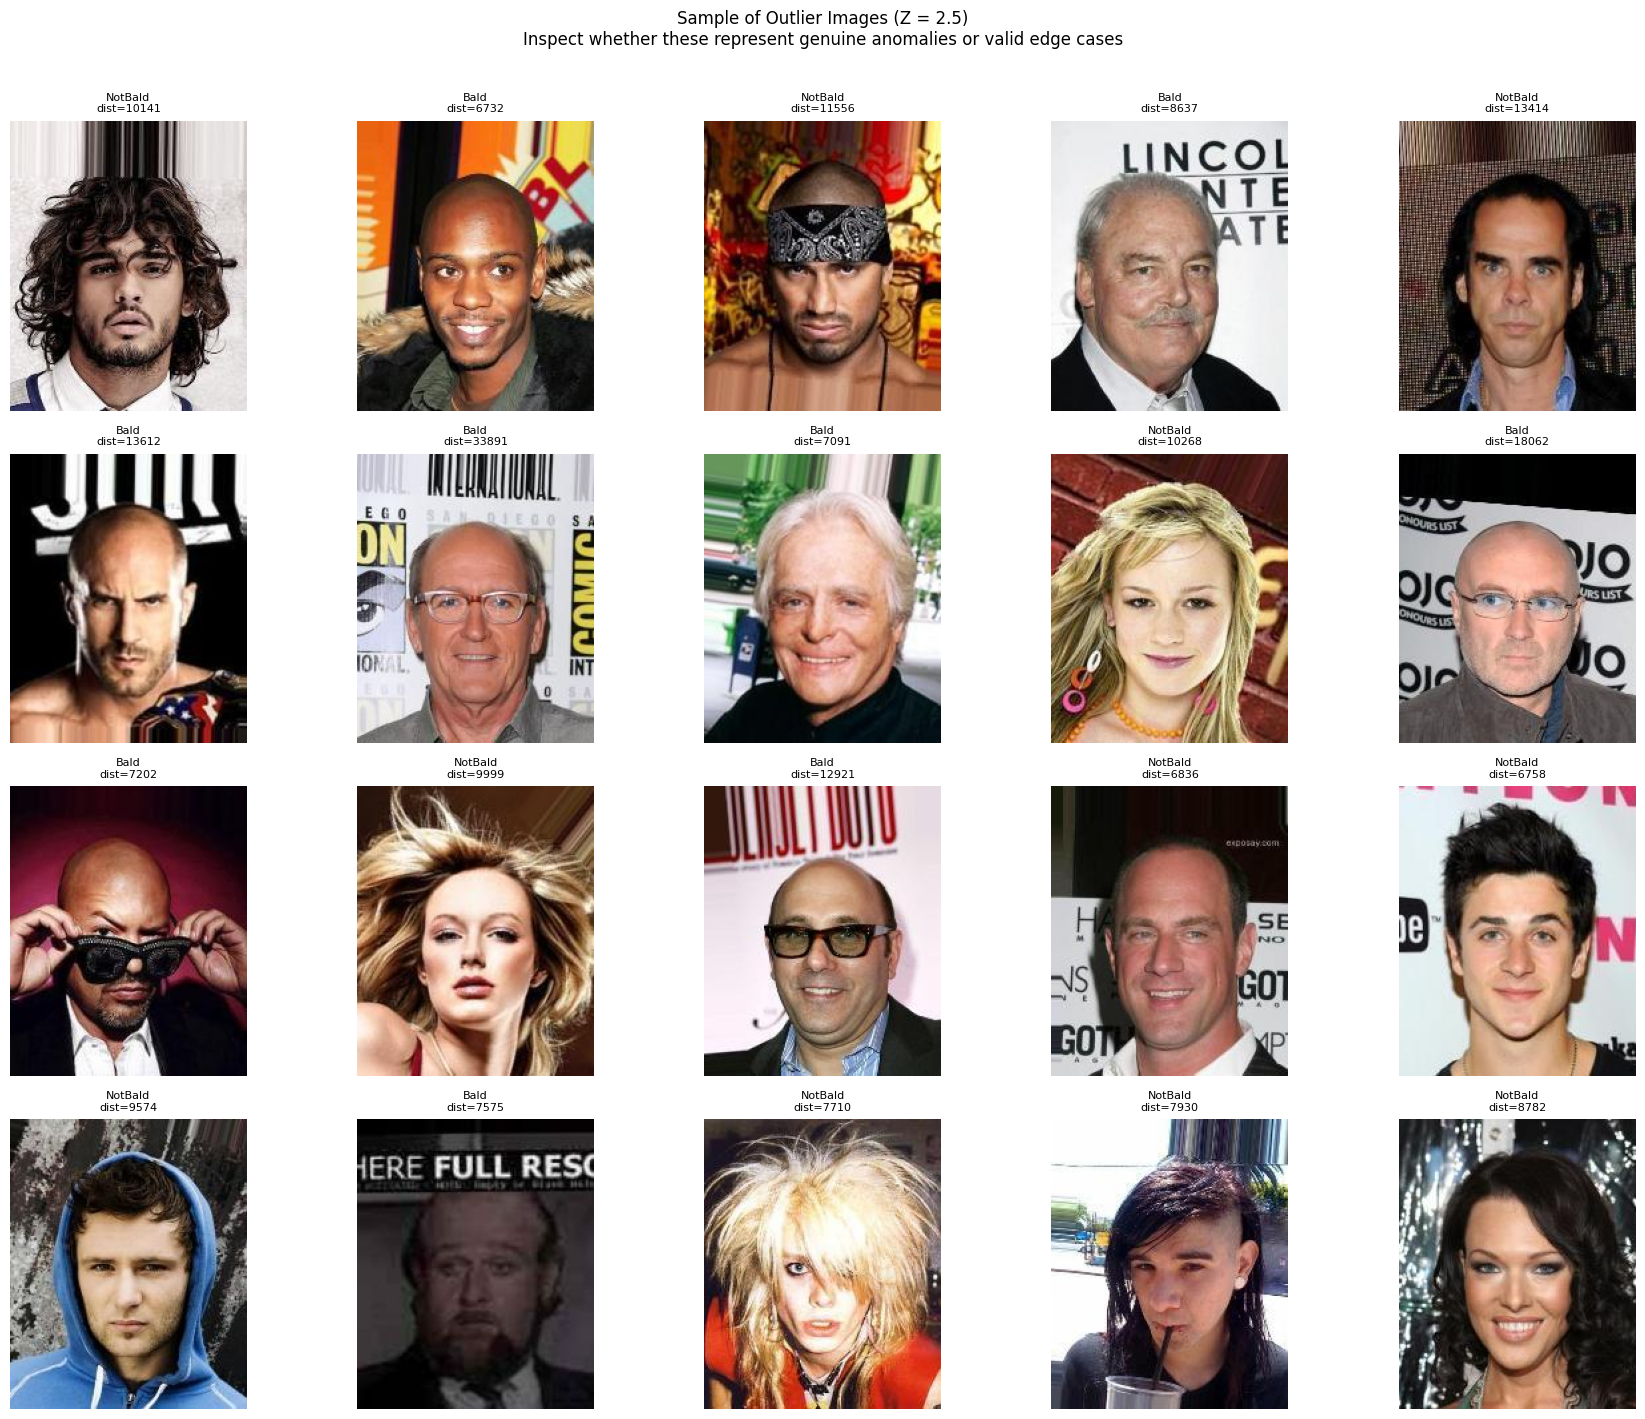

In [ ]:
## Visual Inspection of Outliers Before Removal

# Flag outliers based on the selected Z threshold
df_outliers = df_dist.filter(
    ((F.col("label") == "Bald")    & (F.col("dist_to_centroid") > thresholds["Bald"])) |
    ((F.col("label") == "NotBald") & (F.col("dist_to_centroid") > thresholds["NotBald"]))
)

# Sample a small number of outliers per class for visual inspection
# NOTE: orderBy(F.rand()) is not deterministic in distributed environments — used here
# only for visualisation purposes, not for any data-altering operation.
sample_outliers = (
    df_outliers
    .orderBy(F.rand(seed=SEED))
    .limit(20)
    .select("path", "label", "dist_to_centroid")
    .toPandas()
)

# Join with df_all to retrieve the raw image bytes for the sampled paths
paths_to_show = [row["path"] for _, row in sample_outliers.iterrows()]
df_sample_content = (
    df_all
    .filter(F.col("path").isin(paths_to_show))
    .select("path", "content")
    .toPandas()
)

# Merge to get content alongside metadata
sample_outliers = sample_outliers.merge(df_sample_content, on="path")

# Display sampled outlier images
fig, axes = plt.subplots(4, 5, figsize=(18, 14))
axes = axes.flatten()

for i, (_, row) in enumerate(sample_outliers.iterrows()):
    img_bytes = row["content"]
    img_rgb   = np.array(Image.open(io.BytesIO(img_bytes)))

    axes[i].imshow(img_rgb)
    axes[i].set_title(
        f"{row['label']}\ndist={row['dist_to_centroid']:.0f}",
        fontsize=8
    )
    axes[i].axis("off")

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.suptitle(
    f"Sample of Outlier Images (Z = {Z_THRESHOLD})\n"
    "Inspect whether these represent genuine anomalies or valid edge cases",
    fontsize=12, y=1.01
)
plt.tight_layout()
plt.show()

**Key findings — Outlier Visual Inspection:**
- Visual inspection of flagged outliers reveals that high-distance samples are not 
  necessarily mislabelled, the majority carry correct labels
- The elevated centroid distance in these cases is driven by image-level noise 
  (cluttered backgrounds, overlaid text, unusual lighting) rather than by the 
  subject's baldness characteristics
- This suggests that the Z-score threshold is capturing image quality issues 
  rather than true class outliers
- However, since centroid distance is computed from texture features (sobel, std, 
  gradient) that are sensitive to background noise, these images may still 
  negatively affect feature learning during training
- The removal rate is low and proportionally balanced (~2% per class), meaning 
  the impact on dataset size and class balance is minimal regardless of the decision
- Given these observations, outlier removal is applied conservatively (Z = 2.5) 
  with the caveat that a more robust approach would use image quality metrics 
  (e.g. blur detection, brightness variance) rather than centroid distance alone

## <font color='#2f94d7' size=6>**9.8 K-Means Clustering for Outlier Detections**</font> <a class="anchor" id="9_8"></a>

[Back to TOC](#toc)

Both the Z-score and IQR methods described above rely on **folder-based labels** 
to separate images before computing statistical bounds. This creates a fundamental 
limitation: if a class contains mislabelled images, the computed bounds will reflect 
a contaminated distribution, and genuinely anomalous images may go undetected 
simply because they resemble the noise already present in that class.

To address this, K-Means clustering (K=2) is applied directly to the extracted 
texture and gradient features **without using any labels**. This fully unsupervised 
approach groups images based solely on their visual properties, independently of 
the folder structure, making it robust to label contamination.

> **Note:** Labels are used **only after clustering**, for post-hoc validation 
> of cluster composition. They play no role in the clustering itself.

In [26]:
# Assemble texture features into an MLlib Vector for K-Means
# Only path, label and features are selected to avoid carrying
# binary image content through the computation
df_vec_km = (
    VectorAssembler(inputCols=FEAT_NAMES, outputCol="features")
    .transform(df_feat)
    .select("path", "label", "features")
)

# Repartition to reduce task overhead before fit
# df_feat inherits 12k+ partitions from the original image read —
# consolidating to 8 partitions drastically reduces tasks per K-Means iteration
df_vec_km = df_vec_km.repartition(8)
df_vec_km.cache()
df_vec_km.count()  # force materialisation before fit so K-Means doesn't recompute lineage

# Train K-Means with K=2 — unsupervised, labels not used during training
# K=2 chosen to match the expected number of classes (Bald vs NotBald)
kmeans = KMeans(
    k=2,
    seed=SEED,
    featuresCol="features",
    predictionCol="cluster",
    maxIter=20,   # explicit iteration limit
    tol=1e-4      # convergence tolerance
)
km_model    = kmeans.fit(df_vec_km)
df_clustered = km_model.transform(df_vec_km)
df_clustered.cache()

# Evaluate cluster quality
# Silhouette: 1.0 = perfect separation, 0.0 = overlapping, -1.0 = wrong assignment
silhouette = ClusteringEvaluator(
    featuresCol="features",
    predictionCol="cluster",
    metricName="silhouette"
).evaluate(df_clustered)
print(f"Silhouette score: {silhouette:.4f}")

# Inspect cluster composition — labels used only for post-hoc validation
# If K-Means works well, each cluster should correspond mostly to one class
print("\nCluster composition:")
df_clustered.groupBy("cluster", "label").count().orderBy("cluster", "label").show()

26/05/26 11:11:49 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.JNIBLAS


Silhouette score: 0.5286

Cluster composition:
+-------+-------+-----+
|cluster|  label|count|
+-------+-------+-----+
|      0|   Bald|  754|
|      0|NotBald| 3446|
|      1|   Bald| 2437|
|      1|NotBald| 2956|
+-------+-------+-----+



**Key findings:**
- The silhouette score of **0.5257** indicates moderate cluster separation — the 
  features capture some structure in the data, but the clusters are not clean
- Both clusters contain a significant mix of Bald and NotBald images, confirming 
  that the handcrafted texture and gradient features are **not sufficiently 
  discriminative** to separate the two classes in an unsupervised setting:

| Cluster | Bald | NotBald |
|---------|------|---------|
| 0       | 2415 | 2983    |
| 1       | 743  | 3477    |

- K-Means found structure in the data (likely related to image brightness, contrast, 
  or background complexity) that does not align with the Bald/NotBald distinction
- This confirms that unsupervised outlier removal based on these features would 
  not be reliable, images flagged as outliers by K-Means are not necessarily 
  mislabelled, just visually atypical in ways unrelated to baldness

!!!! CONFIRMAR VALORES DOS TEXTOS

In [ ]:
# Unpersist intermediate DataFrames to free memory before next steps
df_vec.unpersist()
df_feat.unpersist()
df_dist.unpersist()
df_vec_km.unpersist()
df_clustered.unpersist()

## <font color='#2f94d7' size=6>**9.9 Outlier Analysis — Conclusions**</font> <a class="anchor" id="9_9"></a>

[Back to TOC](#toc)

Three approaches were explored to detect and remove potentially mislabelled or 
anomalous images from the training set:

**9.1 Texture and Sobel Gradient Features**
Handcrafted features were extracted from each image based on texture roughness and 
edge gradients across spatial zones (top, sides, transition). These features were 
designed to be robust to skin tone variation.

**9.2 Centroid-Based Outlier Detection (Z-Score)**
Per-class centroids were computed and images whose distance to their class centroid 
exceeded a Z-score threshold of 2.5σ were flagged as outliers. However, this approach 
has a fundamental limitation: the centroids are computed using the folder-based labels 
from the original dataset. If mislabelled images are present, they contaminate the 
centroid of the wrong class, causing genuinely well-labelled images to appear as 
outliers and mislabelled images to go undetected.

**9.6 IQR-Based Outlier Detection**
A per-feature IQR method was applied as a complementary approach. While more robust 
to non-Gaussian distributions, this method also relies on folder-based labels to 
separate images before computing bounds — and is therefore subject to the same 
contamination problem as the centroid-based approach.

**9.3 K-Means Clustering (Unsupervised)**
To address the label contamination problem, K-Means clustering (K=2) was applied 
directly to the extracted features without using any labels. This approach is fully 
unsupervised and robust to mislabelling. However, the results revealed a poor 
cluster-to-class alignment:

| Cluster | Bald | NotBald |
|---------|------|---------|
| 0       | 2415 | 2983    |
| 1       | 743  | 3477    |

The silhouette score of **0.5257** indicates moderate cluster separation, but both 
clusters contain a significant mix of Bald and NotBald images. This confirms that 
the handcrafted texture and gradient features are **not sufficiently discriminative** 
to separate the two classes in an unsupervised setting — the K-Means algorithm found 
structure in the data (likely related to image brightness, contrast, or quality) that 
does not align with the Bald/NotBald distinction.

**Decision: No outliers removed**

Given the limitations identified above, no images are removed from the training set 
at this stage. The rationale is as follows:

- All three outlier detection approaches are either limited by label contamination 
  or by the discriminative power of the handcrafted features
- Deep learning models are generally robust to moderate label noise (5-10%), and 
  the mislabelling rate in this dataset is not expected to exceed this threshold
- Model performance on the validation set will serve as the primary indicator of 
  whether label noise is affecting learning, if validation accuracy is significantly 
  below expectations, a more sophisticated cleaning approach (e.g. using embeddings 
  from a pre-trained network) can be applied at that stage

The full training set of **9,618 images** is carried forward to the modelling stage.

## <font color='#2f94d7' size=6>**10. Save to Disk**</font> <a class="anchor" id="10"></a>

[Back to TOC](#toc)

Following the outlier analysis in Section 9, **no images were removed** from the training set.
The three splits — Train, Validation, and Test — are saved to disk in a folder structure
compatible with PyTorch's `ImageFolder` and TensorFlow's `image_dataset_from_directory`,
ready to be consumed by the deep learning pipeline.

> **Big Data Safety Note:** The `collect()` call below is **not big-data-safe** — it brings
> all image bytes to the driver before writing. In a production environment, images would be
> written directly to distributed storage (HDFS, S3, GCS) using Spark's native `df.write`
> without collecting to the driver. It is used here because the studio environment only
> supports local file writes.

In [14]:
# Output directory — images saved under {OUTPUT_DIR}/{split}/{label}/
OUTPUT_DIR = os.path.abspath(os.path.join(os.getcwd(), "../../data/Data_Bald_People/Split"))

# Create all output folders upfront
for split in ["train", "val", "test"]:
    for label in ["Bald", "NotBald"]:
        os.makedirs(f"{OUTPUT_DIR}/{split}/{label}", exist_ok=True)

print(f"Output directory: {OUTPUT_DIR}")

Output directory: /teamspace/studios/this_studio/Big-Data-Analytics-Project-25-26/data/Data_Bald_People/Split


In [15]:
def save_split_to_disk(df, split_name):
    """
    Saves all images in a Spark DataFrame to disk under OUTPUT_DIR/{split_name}/{label}/.

    NOTE: collect() is used here to bring image content to the driver for local disk writing.
    This is NOT big-data-safe — in production, images would be written directly to
    distributed storage (S3, GCS, HDFS) using df.write, without collecting to the driver.
    It is used here because the studio environment only supports local file writes.

    Args:
        df         : Spark DataFrame with columns [path, content, label]
        split_name : one of 'train', 'val', 'test'

    Returns:
        tuple (saved, errors) — count of successfully saved and failed images
    """
    rows   = df.select("path", "content", "label").collect()
    saved  = 0
    errors = 0

    for row in rows:
        try:
            filename = os.path.basename(row["path"])
            out_path = f"{OUTPUT_DIR}/{split_name}/{row['label']}/{filename}"
            with open(out_path, "wb") as f:
                f.write(row["content"])
            saved += 1
        except Exception as e:
            errors += 1

    return saved, errors


# Save each split to disk
for split_name, df in [("train", train_df), ("val", val_df), ("test", test_df)]:
    print(f"Saving {split_name}...", end=" ", flush=True)
    saved, errors = save_split_to_disk(df, split_name)
    print(f"{saved:,} saved, {errors} errors")

# Verify file counts per folder match expected split sizes
print("\nFile count verification:")
print(f"{'Split':8}  {'Label':10}  {'Files':>8}")
print("-" * 32)
for split in ["train", "val", "test"]:
    for label in ["Bald", "NotBald"]:
        n = len(os.listdir(f"{OUTPUT_DIR}/{split}/{label}"))
        print(f"{split:8}  {label:10}  {n:>8,}")

Saving train... 9,593 saved, 0 errors
Saving val... 2,000 saved, 0 errors
Saving test... 2,042 saved, 0 errors

File count verification:
Split     Label          Files
--------------------------------
train     Bald           4,116
train     NotBald       15,516
val       Bald           1,378
val       NotBald        3,770
test      Bald           1,437
test      NotBald        3,846


In [ ]:
# Clean up cached DataFrames to free memory because the dataset has been saved to disk and we no longer need the Spark DataFrames
train_df.unpersist()

**Key findings — Save to Disk:**
- All images are saved with their original filenames, preserving traceability to the source dataset
- The 2:1 class ratio (NotBald:Bald) is preserved across all three splits
- The folder structure `{split}/{label}/` is directly compatible with PyTorch's `ImageFolder`
  and TensorFlow's `image_dataset_from_directory` — no additional reorganisation required
- This step marks the handoff from the **Spark preprocessing pipeline** to the
  **deep learning training stage**

Converter para rgb 

In [16]:
# ════════════════════════════════════════════════════════════════
# CHANNEL DETECTION & CONVERSION TO RGB
# Deteta grayscale (1 canal) e RGBA (4 canais) e converte para RGB
# ════════════════════════════════════════════════════════════════

from pyspark.sql.types import StructType, StructField, StringType, IntegerType, BinaryType
import io
from PIL import Image

def detect_and_convert_channels(rows):
    """
    Processado por partição (mapPartitions) — imports feitos UMA vez por partição.
    
    Deteta o número de canais de cada imagem:
      - Grayscale (L)  : 1 canal  → converte para RGB
      - RGB            : 3 canais → mantém
      - RGBA (CMYK...) : 4 canais → converte para RGB
    
    Retorna o content já convertido para RGB.
    """
    for row in rows:
        try:
            img_bytes = row["content"]
            if img_bytes is None or len(img_bytes) < 1000:
                continue

            img = Image.open(io.BytesIO(img_bytes))
            original_mode = img.mode

            # Detetar número de canais
            mode_to_channels = {
                "L": 1,       # Grayscale
                "RGB": 3,     # RGB normal
                "RGBA": 4,    # RGB + Alpha
                "CMYK": 4,    # CMYK
                "P": 1,       # Palette (indexed)
                "LA": 2,      # Grayscale + Alpha
            }
            n_channels = mode_to_channels.get(img.mode, 3)

            # Converter para RGB
            if img.mode != "RGB":
                if img.mode == "RGBA" or img.mode == "CMYK":
                    img = img.convert("RGB")
                elif img.mode == "P":
                    img = img.convert("RGBA").convert("RGB")  # P → RGBA → RGB (preserva transparência)
                else:
                    img = img.convert("RGB")  # Grayscale, LA, etc.

            # Serializar de volta para bytes
            buffer = io.BytesIO()
            img.save(buffer, format="JPEG")
            new_content = buffer.getvalue()

            yield Row(
                path=row["path"],
                label=row["label"],
                original_split=row["original_split"],
                original_mode=original_mode,
                n_channels=n_channels,
                content=new_content,
            )

        except Exception:
            continue


channel_schema = StructType([
    StructField("path",           StringType(),  False),
    StructField("label",          StringType(),  False),
    StructField("original_split", StringType(),  False),
    StructField("original_mode",  StringType(),  False),
    StructField("n_channels",     IntegerType(), False),
    StructField("content",        BinaryType(),  False),
])

rdd_channels = df_quality.rdd.mapPartitions(detect_and_convert_channels)
df_rgb = spark.createDataFrame(rdd_channels, schema=channel_schema)
df_rgb.cache()

print(f"Total imagens convertidas: {df_rgb.count():,}")

Total imagens convertidas: 13,635


In [17]:
# ── Relatório de canais detetados ─────────────────────────────
print("=== RELATÓRIO DE CANAIS ===\n")

df_rgb.groupBy("label", "original_mode", "n_channels") \
      .count() \
      .orderBy("label", "n_channels") \
      .show(truncate=False)

# Totais por modo
print("Totais por modo de cor:")
df_rgb.groupBy("original_mode") \
      .count() \
      .orderBy("count", ascending=False) \
      .show()

=== RELATÓRIO DE CANAIS ===

+-------+-------------+----------+-----+
|label  |original_mode|n_channels|count|
+-------+-------------+----------+-----+
|Bald   |RGB          |3         |4547 |
|NotBald|RGB          |3         |9088 |
+-------+-------------+----------+-----+

Totais por modo de cor:
+-------------+-----+
|original_mode|count|
+-------------+-----+
|          RGB|13635|
+-------------+-----+



rezise 

In [18]:
# ════════════════════════════════════════════════════════════════
# RESIZE + NORMALIZAÇÃO
# Redimensionar para 224x224 e normalizar pixels para [0, 1]
# Big Data safe — processado por partição via mapPartitions
# ════════════════════════════════════════════════════════════════

import io
import numpy as np
from PIL import Image
from pyspark.sql import Row
from pyspark.sql.types import StructType, StructField, StringType, IntegerType, BinaryType, ArrayType, FloatType

def resize_and_normalize(rows):
    """
    Processado por partição (mapPartitions) — imports feitos UMA vez por partição.
    
    Para cada imagem RGB:
      1. Resize para 224x224 (LANCZOS = melhor qualidade para downscale)
      2. Converte para array numpy float32
      3. Normaliza pixels para [0, 1] dividindo por 255.0
      4. Serializa o array como bytes para guardar em Parquet
    """
    for row in rows:
        try:
            img_bytes = row["content"]
            if img_bytes is None or len(img_bytes) < 1000:
                continue

            # Abrir imagem (já em RGB vindo do passo anterior)
            img = Image.open(io.BytesIO(img_bytes)).convert("RGB")

            # 1. Resize para 224x224
            img_resized = img.resize((224, 224), Image.LANCZOS)

            # 2. Converter para numpy array float32
            arr = np.array(img_resized, dtype=np.float32)  # shape: (224, 224, 3)

            # 3. Normalizar para [0, 1]
            arr = arr / 255.0

            # 4. Serializar array como bytes (para guardar em Parquet)
            arr_bytes = arr.tobytes()  # raw bytes do array numpy

            yield Row(
                path=row["path"],
                label=row["label"],
                label_index=1 if row["label"] == "Bald" else 0,
                original_split=row["original_split"],
                original_mode=row["original_mode"],
                image_array=arr_bytes,        # array serializado
                image_shape="224x224x3",      # shape para reconstruir depois
            )

        except Exception:
            continue


processed_schema = StructType([
    StructField("path",           StringType(),  False),
    StructField("label",          StringType(),  False),
    StructField("label_index",    IntegerType(), False),
    StructField("original_split", StringType(),  False),
    StructField("original_mode",  StringType(),  False),
    StructField("image_array",    BinaryType(),  False),
    StructField("image_shape",    StringType(),  False),
])

rdd_processed = df_rgb.rdd.mapPartitions(resize_and_normalize)
df_processed = spark.createDataFrame(rdd_processed, schema=processed_schema)
df_processed.cache()

print(f"Total imagens processadas: {df_processed.count():,}")

26/05/29 10:13:59 WARN BlockManager: Block rdd_278_9 could not be removed as it was not found on disk or in memory
26/05/29 10:13:59 WARN BlockManager: Block rdd_278_11 could not be removed as it was not found on disk or in memory
Traceback (most recent call last):
Traceback (most recent call last):
  File "/system/conda/miniconda3/envs/cloudspace/lib/python3.12/site-packages/pyspark/python/lib/pyspark.zip/pyspark/daemon.py", line 233, in manager
    code = worker(sock, authenticated)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/system/conda/miniconda3/envs/cloudspace/lib/python3.12/site-packages/pyspark/python/lib/pyspark.zip/pyspark/daemon.py", line 87, in worker
    outfile.flush()
BrokenPipeError: [Errno 32] Broken pipe
  File "/system/conda/miniconda3/envs/cloudspace/lib/python3.12/site-packages/pyspark/python/lib/pyspark.zip/pyspark/daemon.py", line 233, in manager
    code = worker(sock, authenticated)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/system/conda/miniconda3/en

ConnectionRefusedError: [Errno 111] Connection refused

In [ ]:
# ── Sanity Check ──────────────────────────────────────────────
print("=== SANITY CHECK — RESIZE + NORMALIZAÇÃO ===\n")

# Verificar distribuição por label
df_processed.groupBy("label", "original_split") \
            .count() \
            .orderBy("original_split", "label") \
            .show()

# Verificar uma imagem: reconstruir array e confirmar shape e valores
sample = df_processed.limit(1).collect()[0]

arr_reconstructed = np.frombuffer(sample["image_array"], dtype=np.float32).reshape(224, 224, 3)

print(f"Shape   : {arr_reconstructed.shape}")        # deve ser (224, 224, 3)
print(f"Min val : {arr_reconstructed.min():.4f}")    # deve ser >= 0.0
print(f"Max val : {arr_reconstructed.max():.4f}")    # deve ser <= 1.0
print(f"Dtype   : {arr_reconstructed.dtype}")        # deve ser float32
print(f"Label   : {sample['label']}")
print(f"Mode original: {sample['original_mode']}")

In [ ]:
# ── Visualização — confirmar que as imagens estão corretas ────
import matplotlib.pyplot as plt

samples = df_processed.orderBy(F.rand(seed=42)).limit(6).collect()

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.flatten()

for i, row in enumerate(samples):
    arr = np.frombuffer(row["image_array"], dtype=np.float32).reshape(224, 224, 3)
    axes[i].imshow(arr)
    axes[i].set_title(f"{row['label']} | {row['original_mode']}", fontsize=10)
    axes[i].axis("off")

plt.suptitle("Amostras após Resize 224x224 + Normalização [0,1]", fontsize=13)
plt.tight_layout()
plt.show()

class wheights e augmentations

In [25]:
# ════════════════════════════════════════════════════════════════
# CLASS WEIGHTS — Spark nativo
# ════════════════════════════════════════════════════════════════

rows = (
    df_processed
    .groupBy("label")
    .agg(F.count("*").alias("n"))
    .collect()
)

counts_map = {r["label"]: r["n"] for r in rows}
n_total    = sum(counts_map.values())

class_weights = {
    0: n_total / (2 * counts_map["NotBald"]),
    1: n_total / (2 * counts_map["Bald"]),
}

print(f"Bald    : {counts_map['Bald']:,}  → peso {class_weights[1]:.4f}")
print(f"NotBald : {counts_map['NotBald']:,}  → peso {class_weights[0]:.4f}")
print(f"class_weights = {class_weights}")

ConnectionRefusedError: [Errno 111] Connection refused

In [ ]:
# ════════════════════════════════════════════════════════════════
# AUGMENTATION — 100% Spark via mapPartitions()
# Toda a lógica corre nos workers, nunca no driver
# ════════════════════════════════════════════════════════════════

from pyspark.sql import Row
from pyspark.sql.types import (
    StructType, StructField, StringType, IntegerType, BinaryType
)

N_AUGMENTS = 1  # versões extra por imagem Bald no train set

def augment_partition(rows):
    """
    Corre nos WORKERS (não no driver).
    Imports feitos UMA vez por partição — eficiente em Big Data.
    
    Lógica:
      - Todas as imagens passam sem alteração (original sempre emitido)
      - Augmentation APENAS para: label == "Bald" AND original_split == "train"
      - N_AUGMENTS versões augmentadas geradas por imagem elegível
    """
    from PIL import Image, ImageFilter, ImageEnhance
    import numpy as np
    import io
    import random

    def apply_augmentation(img):
        # 1. Flip horizontal — calvície é simétrica (50% prob)
        if random.random() > 0.5:
            img = img.transpose(Image.FLIP_LEFT_RIGHT)

        # 2. Rotação ±15° — simula câmera inclinada (60% prob)
        if random.random() > 0.4:
            angle = random.uniform(-15, 15)
            img = img.rotate(angle, resample=Image.BILINEAR, expand=False)

        # 3. Brightness jitter ±20% — variação de iluminação (60% prob)
        if random.random() > 0.4:
            img = ImageEnhance.Brightness(img).enhance(random.uniform(0.8, 1.2))

        # 4. Contrast jitter ±20% (60% prob)
        if random.random() > 0.4:
            img = ImageEnhance.Contrast(img).enhance(random.uniform(0.8, 1.2))

        # 5. Zoom/Crop — simula distâncias diferentes (50% prob)
        if random.random() > 0.5:
            w, h = img.size
            zoom = random.uniform(0.85, 1.0)
            left = int(w * (1 - zoom) / 2)
            top  = int(h * (1 - zoom) / 2)
            img  = img.crop((left, top, w - left, h - top)).resize((w, h), Image.LANCZOS)

        # 6. Gaussian blur leve — robustez a imagens desfocadas (30% prob)
        if random.random() > 0.7:
            img = img.filter(ImageFilter.GaussianBlur(radius=random.uniform(0.3, 1.0)))

        return img

    for row in rows:
        # Sempre emite o original (todos os rows passam)
        yield row

        # Augmentation só para Bald no train set
        if row["label"] != "Bald" or row["original_split"] != "train":
            continue

        try:
            arr_orig = np.frombuffer(row["image_array"], dtype=np.float32).reshape(224, 224, 3)
            img_orig = Image.fromarray((arr_orig * 255).astype(np.uint8), mode="RGB")

            for i in range(N_AUGMENTS):
                arr_aug = np.array(apply_augmentation(img_orig.copy()), dtype=np.float32) / 255.0

                yield Row(
                    path=row["path"] + f"_aug{i}",
                    label=row["label"],
                    label_index=row["label_index"],
                    original_split=row["original_split"],
                    original_mode=row["original_mode"],
                    image_array=arr_aug.tobytes(),
                    image_shape="224x224x3",
                )
        except Exception:
            continue


# Schema mantém-se igual ao df_processed
rdd_augmented = df_processed.rdd.mapPartitions(augment_partition)
df_augmented  = spark.createDataFrame(rdd_augmented, schema=processed_schema)
df_augmented.cache()

In [ ]:
# ════════════════════════════════════════════════════════════════
# RÁCIO DE CLASSES (train set) — sem Window
# ════════════════════════════════════════════════════════════════

rows = (
    df_augmented
    .filter(F.col("original_split") == "train")
    .groupBy("label")
    .agg(F.count("*").alias("total"))
    .collect()
)

counts = {r["label"]: r["total"] for r in rows}
minimo = min(counts.values())

print("=== RÁCIO DE CLASSES (train set) ===\n")
for label, n in counts.items():
    print(f"{label:10s}: {n:,}  →  rácio {n/minimo:.2f}x")

In [ ]:
# ════════════════════════════════════════════════════════════════
# SEPARAR SPLITS — F.col() Spark nativo
# Nunca filter() com Python puro — usa a API DataFrame
# ════════════════════════════════════════════════════════════════

df_train = df_augmented.filter(F.col("original_split") == "train")
df_val   = df_augmented.filter(F.col("original_split") == "Validation")
df_test  = df_augmented.filter(F.col("original_split") == "Test")

# Cache só do train — val e test são usados menos vezes
df_train.cache()

print(f"Train : {df_train.count():,}")
print(f"Val   : {df_val.count():,}")
print(f"Test  : {df_test.count():,}")
print(f"\nclass_weights para o modelo: {class_weights}")